In [1]:
import pickle
import itertools

import numpy as np
import matplotlib.pyplot as plt

from sklearn.manifold import Isomap

In [2]:
run_name = "minmax_95_5_prank_3"
with open(f"data/eda_results/eda_human_{run_name}.pkl", "rb") as f:
    results = pickle.load(f)
pf = results["converged_pf_table"][-1]

In [3]:
# colorcode pf solutions
pf_norm = (pf - pf.min(axis=0)) / (pf.max(axis=0) - pf.min(axis=0))
weights = pf_norm / pf_norm.sum(axis=1, keepdims=True)
dominant_obj = np.argmax(weights, axis=1)

In [4]:
isomap = Isomap(n_neighbors=50, n_components=4)
isomap.fit_transform(pf)

array([[ 46.72358246,  -2.25073136, -46.15902398,   5.39041972],
       [ 29.40208128, -43.13491653, -26.0810381 ,  -2.50981853],
       [ 33.20472847, -29.58458484, -38.87350525,  11.85605726],
       ...,
       [-32.13638083,  12.92825012,  27.19083534,  11.48756541],
       [-26.53074467,  32.66953814,  22.28988379,  19.75139433],
       [-42.07142801,  20.42615576,  20.47276514,   0.05749942]])

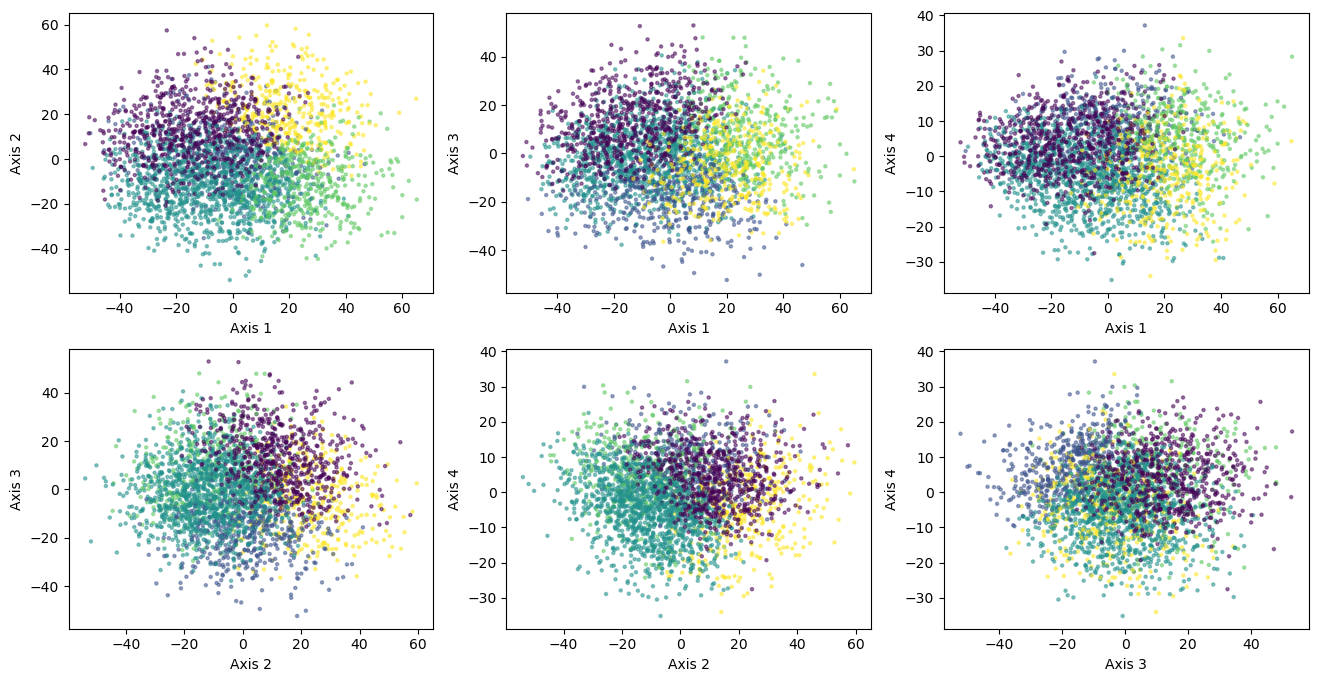

In [ ]:
pf_low_dim = isomap.embedding_

axis_pairs = list(itertools.combinations(range(4), 2)) 
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.ravel()
for ax, (a, b) in zip(axes, axis_pairs):
    ax.scatter(pf_low_dim[:, a], pf_low_dim[:, b], c=dominant_obj, cmap=plt.cm.viridis, alpha=0.5)
    ax.set_xlabel(f"Axis {a + 1}")
    ax.set_ylabel(f"Axis {b + 1}")

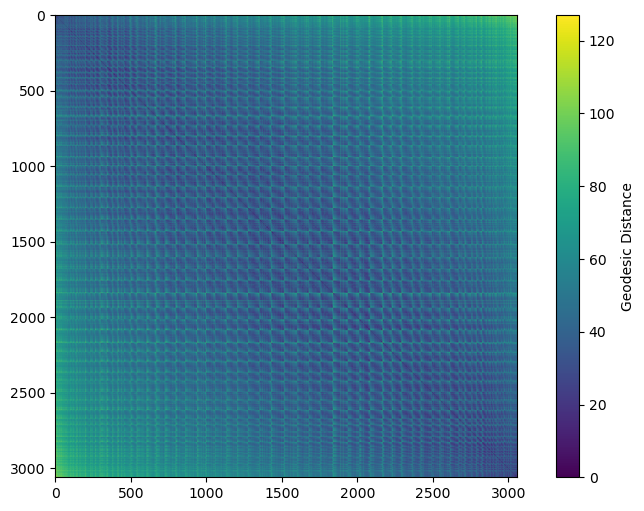

In [19]:
geodesics = isomap.dist_matrix_
fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(geodesics, cmap="viridis")
fig.colorbar(im, ax=ax, label="Geodesic Distance")
plt.show()

In [ ]:
# compare different num of neighbors
for k in range(5, 50, 10):
    isomap = Isomap(n_neighbors=k, n_components=4)
    isomap.fit_transform(pf)
    print(k, isomap.reconstruction_error())

In [ ]:
# compare different num of dimensions
for d in range(1, 6):
    isomap = Isomap(n_neighbors=50, n_components=d)
    isomap.fit_transform(pf)
    print(d, isomap.reconstruction_error())